# CODIGO DE APLICACIÓN A UN DATASET DE OTRO PERIODO

Vamos a ejecutar el código contra los datos de Airbnb de junio de 2025 para ver si extrae los resultados

*NOTA: Para poder usar este código de ejecución hay que lanzarlo desde exactamente el mismo entorno en el que fue realizado el proyecto.*

*Se puede instalar ese entorno en la nueva máquina usando el environment.yml que creamos en el set up del proyecto*

*Copiar el 007_airbnb.yml que tenemos en la carpeta Documentos, al directorio y en el terminal o anaconda prompt ejecutar:*

conda env create --file 007_airbnb.yml --name 007_airbnb

In [3]:
#Importamos los paquetes necesarios
import cloudpickle
import pandas as pd
import sqlalchemy as sa
from janitor import clean_names
import sqlite3

# PRECIO_M2 IDEALISTA
#Ruta del proyecto
ruta_proyecto = 'C:/Users/Oscar/OneDrive - FM4/Escritorio/EVOLVE\Data Science/Proyecto-Master-DataScience-Evolve-OscarFraile'

#Nombre del fichero de datos
nombre_fichero_datos = 'precios_idealista_Dic24.csv'

#Cargar los datos
ruta_completa = ruta_proyecto + '/02_Datos/01_Originales/' + nombre_fichero_datos
precio_m2 = pd.read_csv(ruta_completa)

#Pipeline con las modificaciones hechas en la tabla
nombre_pipe = 'pipe_idealista.pickle'
ruta_pipe = ruta_proyecto + '/04_Modelos/' + nombre_pipe
with open(ruta_pipe, mode='rb') as file:
    pipe_idealista = cloudpickle.load(file)

precio_m2 = pipe_idealista.transform(precio_m2)


# LISTINGS AIRBNB
#Ruta del proyecto
ruta_proyecto = 'C:/Users/Oscar/OneDrive - FM4/Escritorio/EVOLVE\Data Science/Proyecto-Master-DataScience-Evolve-OscarFraile'

#Nombre del fichero de datos
nombre_fichero_datos = 'listings.csv'

#Cargar los datos
ruta_completa = ruta_proyecto + '/02_Datos/01_Originales/Airbnb_Jun25/' + nombre_fichero_datos
listings = pd.read_csv(ruta_completa)

# LISTINGS_DET AIRBNB
#Ruta del proyecto
ruta_proyecto = 'C:/Users/Oscar/OneDrive - FM4/Escritorio/EVOLVE\Data Science/Proyecto-Master-DataScience-Evolve-OscarFraile'

#Nombre del fichero de datos
nombre_fichero_datos = 'listings_det.csv'

#Cargar los datos
ruta_completa = ruta_proyecto + '/02_Datos/01_Originales/Airbnb_Jun25/' + nombre_fichero_datos
listings_det = pd.read_csv(ruta_completa)

#Pipeline con las modificaciones hechas en la tabla
nombre_pipe = 'pipe_preparacion_df.pickle'
ruta_pipe = ruta_proyecto + '/04_Modelos/' + nombre_pipe
with open(ruta_pipe, mode='rb') as file:
    pipe_preparacion_df = cloudpickle.load(file)

df = pipe_preparacion_df.transform((listings_det, listings, precio_m2))

#Pipeline con las modificaciones hechas en la tabla
nombre_pipe = 'pipe_calidad_datos.pickle'
ruta_pipe = ruta_proyecto + '/04_Modelos/' + nombre_pipe
with open(ruta_pipe, mode='rb') as file:
    pipe_calidad_datos = cloudpickle.load(file)
    
df = pipe_calidad_datos.transform(df)

#Pipeline con las modificaciones hechas en la tabla
nombre_pipe = 'pipe_gestion_variables.pickle'
ruta_pipe = ruta_proyecto + '/04_Modelos/' + nombre_pipe
with open(ruta_pipe, mode='rb') as file:
    pipe_gestion_variables = cloudpickle.load(file)

df = pipe_gestion_variables.transform(df)

conn_lite = sqlite3.connect(ruta_proyecto + '/02_Datos/01_Originales/airbnb2025.db')

extras_df = df[['id', 'precio_total', 'm2', 'precio_m2']].copy()
extras_df.to_sql('extras_df', con = conn_lite, if_exists = 'replace')

variables_finales = [
'accommodates',
'availability_30',
'availability_365',
'availability_90',
'bedrooms',
'bed',
'calculated_host_listings_count',
'has_availability',
'host_response_rate',
'host_response_time',
'instant_bookable',
'maximum_nights',
'neighbourhood_group',
'price',
'property_type',
'room_type',
'license',
'bathrooms',
'air',
'allowed',
'cleaning',
'hot water iron',
'iron',
'microwave',
'parking',
'refrigerator',
'shampoo',
'tv washer',
'wifi kitchen',
'and silverware',
'body',
'clothing',
'clothing storage',
'coffee',
'elevator',
'hair',
'host_identity_verified',
'host_verifications',
'kitchen essentials',
'allowed',
'basics',
'beds',
'dryer bed',
'hair dryer',
'maker',
'microwave hangers',
'oven',
'stove',
'review_scores_rating',
'review_scores_accuracy',
'review_scores_cleanliness',
'review_scores_checkin',
'review_scores_communication',
'review_scores_location',
'review_scores_value',
'host_is_superhost',
'bathrooms_text',
'precio_m2',
'latitude',
'longitude',
'amenities',
'number_of_reviews']

df = df[variables_finales]

nombre_pipe_ejecucion = 'pipe_ejecucion.pickle'
ruta_pipe_ejecucion = ruta_proyecto + '/04_Modelos/' + nombre_pipe_ejecucion
with open(ruta_pipe_ejecucion, mode='rb') as file:
   pipe_ejecucion = cloudpickle.load(file)

scoring = pipe_ejecucion.predict_proba(df)[:, 1]

df['rentabilidad_predicha'] = scoring
df['rentable'] = df['rentabilidad_predicha'] > 0.5
df['id'] = extras_df['id']
df['precio_total'] = extras_df['precio_total']
df['m2'] = extras_df['m2']

# Rentabilidad del inmueble
ocupacion_media = 0.60  # 60% de ocupación anual
coste_operativo_pct = 0.30  # 30% de los ingresos
df['ingresos_brutos_anuales'] = df['precio_total'] * df['availability_365'] * ocupacion_media
df['beneficio_neto_anual'] = round(df['ingresos_brutos_anuales'] * (1 - coste_operativo_pct),2)

# Estimar el precio de mercado de la vivienda
df['precio_estimado'] = df['precio_m2'] * df['m2']

# Rentabilidad anual en %
df['rentabilidad_anual_pct'] = round((df['beneficio_neto_anual'] / df['precio_estimado']) * 100,2)

df.set_index('id', inplace = True)

C:\Users\Oscar\AppData\Local\Temp\ipykernel_17008\3667475308.py:5: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.


['id', 'name', 'host_id', 'host_since', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'first_review', 'last_review', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'license', 'instant_bookable', 'calculated_host_listings_

In [4]:
df.isna().sum().sort_values(ascending=False)

host_identity_verified       12
maker                         0
review_scores_cleanliness     0
review_scores_accuracy        0
review_scores_rating          0
                             ..
and silverware                0
body                          0
clothing                      0
clothing storage              0
rentabilidad_anual_pct        0
Length: 70, dtype: int64

In [5]:
#Mostrar el máximo de columnas posibles de una tabla
pd.set_option('display.max_columns', None) #Número de columnas que deben verse. None = Máx
df[['neighbourhood_group','room_type','review_scores_value','price','precio_estimado','beneficio_neto_anual','rentabilidad_anual_pct']].loc[(df.beneficio_neto_anual>0)]

,neighbourhood_group,room_type,review_scores_value,price,precio_estimado,beneficio_neto_anual,rentabilidad_anual_pct
id,,,,,,,
21853,Latina,Private room,4.67,29.0,138600,4141.20,2.99
30320,Centro,Entire home/apt,4.69,113.0,308500,15994.02,5.18
40916,Centro,Entire home/apt,4.55,113.0,308500,16705.92,5.42
62423,Centro,Private room,4.59,64.0,308500,10107.28,3.28
70059,Centro,Entire home/apt,4.53,86.0,308500,180.60,0.06
...,...,...,...,...,...,...,...
1440480926395443476,Arganzuela,Private room,0.00,30.0,242500,806.40,0.33
1440487269977127830,Retiro,Entire home/apt,0.00,140.0,499410,17640.00,3.53
1440501514773966682,Centro,Entire home/apt,0.00,77.0,308500,11286.66,3.66


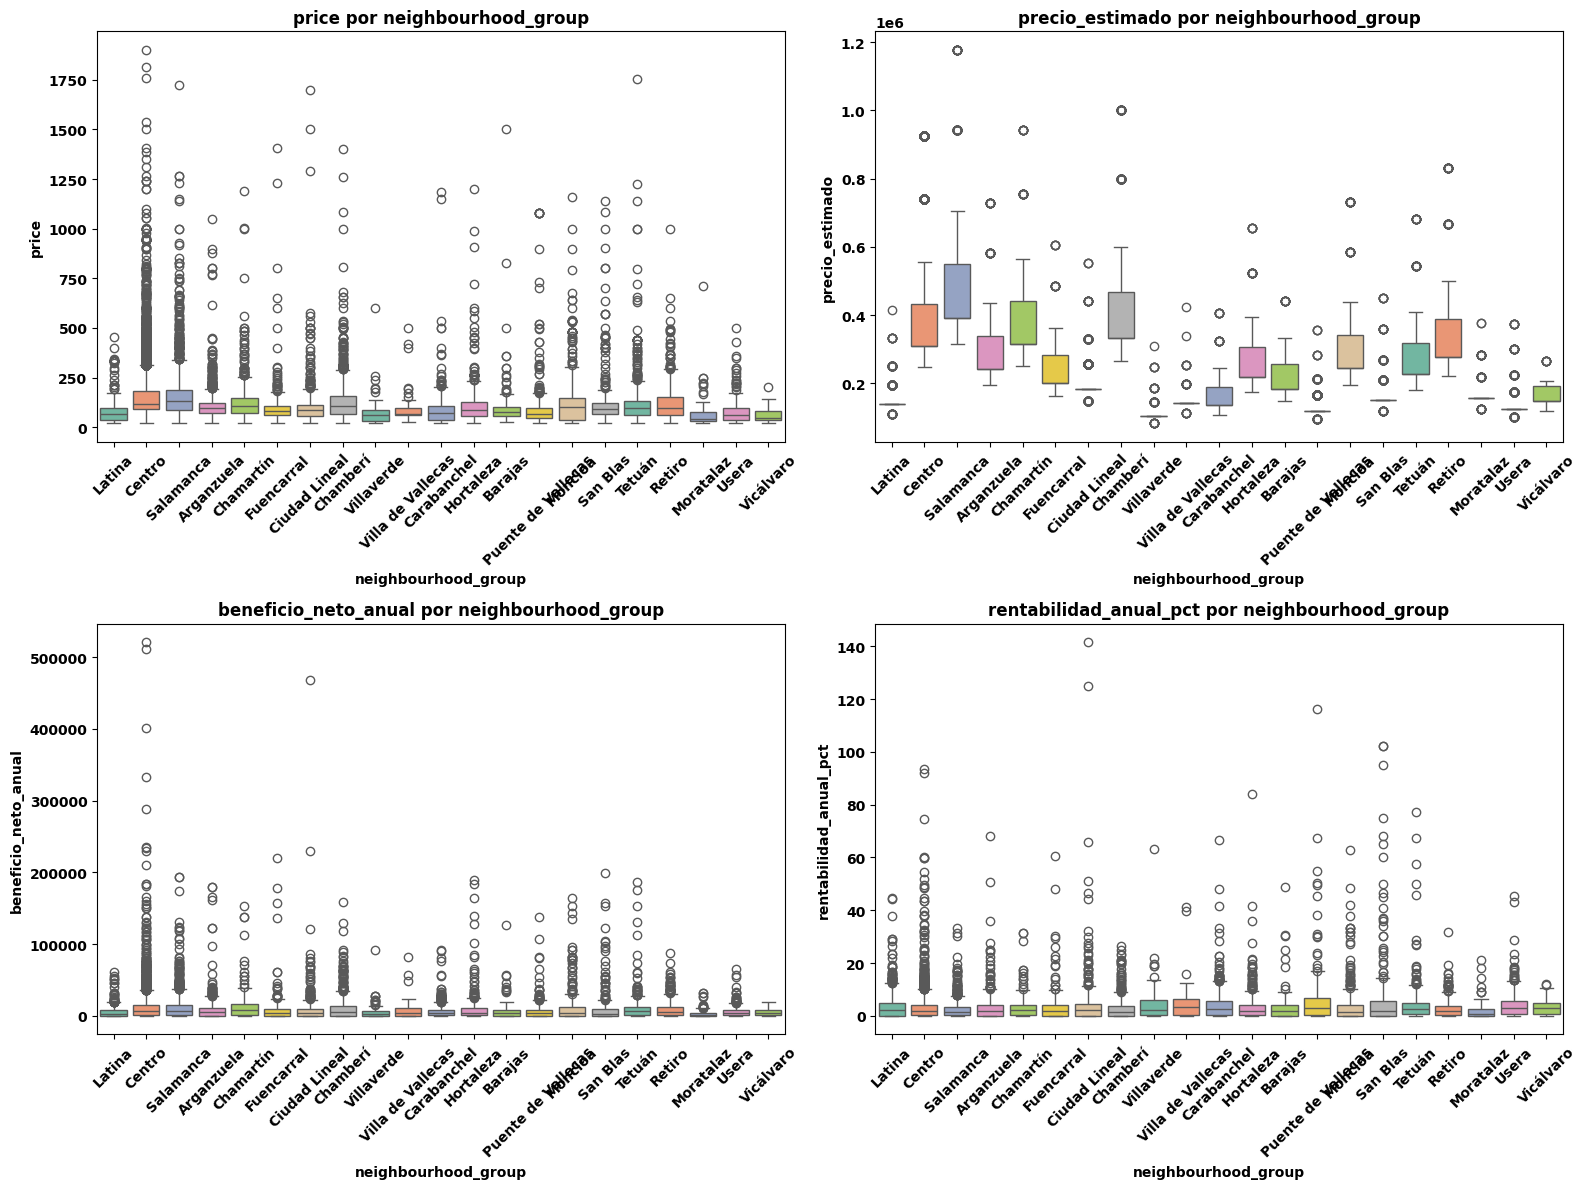

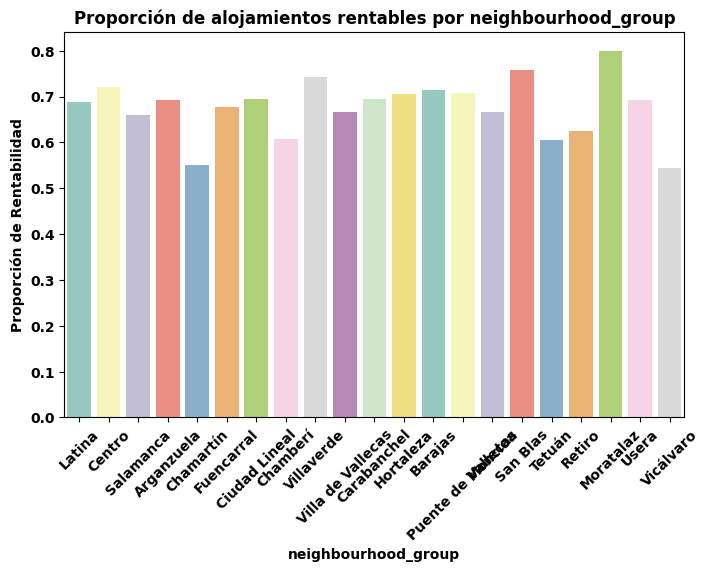

In [6]:
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

# Asegúrate de que los gráficos se vean en notebooks
%matplotlib inline  

# Lista de variables a graficar
variables = ['price', 'precio_estimado', 'beneficio_neto_anual', 'rentabilidad_anual_pct']

# Tamaño del gráfico
plt.figure(figsize=(16, 12))

# Graficar cada variable con boxplot por neighbourhood_group
for i, var in enumerate(variables, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='neighbourhood_group', y=var, data=df, palette='Set2')
    plt.title(f'{var} por neighbourhood_group')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Gráfico de proporción de "rentable" por grupo
plt.figure(figsize=(8, 5))
sns.barplot(
    x='neighbourhood_group',
    y='rentable',
    data=df,
    estimator=lambda x: sum(x) / len(x),
    ci=None,
    palette='Set3'
)
plt.ylabel('Proporción de Rentabilidad')
plt.title('Proporción de alojamientos rentables por neighbourhood_group')
plt.xticks(rotation=45)
plt.show()

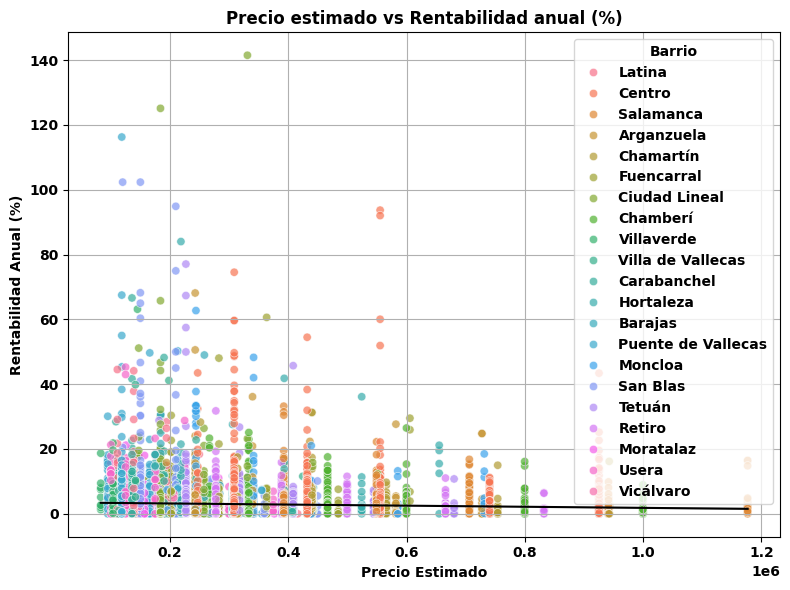

Coeficiente de correlación: -0.05


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot con línea de tendencia
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='precio_estimado', y='rentabilidad_anual_pct', hue='neighbourhood_group', alpha=0.7)
sns.regplot(data=df, x='precio_estimado', y='rentabilidad_anual_pct', scatter=False, color='black', line_kws={"linewidth":1.5})
plt.title('Precio estimado vs Rentabilidad anual (%)')
plt.xlabel('Precio Estimado')
plt.ylabel('Rentabilidad Anual (%)')
plt.legend(title='Barrio')
plt.grid(True)
plt.tight_layout()
plt.show()

# Correlación entre ambas variables
correlacion = df['precio_estimado'].corr(df['rentabilidad_anual_pct'])
print(f'Coeficiente de correlación: {correlacion:.2f}')

In [8]:
top_10 = df[['neighbourhood_group', 'price', 'precio_estimado', 'beneficio_neto_anual', 'rentabilidad_anual_pct']].sort_values(by='rentabilidad_anual_pct', ascending=False).head(50)
top_10

,neighbourhood_group,price,precio_estimado,beneficio_neto_anual,rentabilidad_anual_pct
id,,,,,
34742371,Ciudad Lineal,1700.0,330840,468096.95,141.49
757790127013172621,Ciudad Lineal,1500.0,183800,229950.00,125.11
42330635,Puente de Vallecas,900.0,118350,137592.00,116.26
774773851284478554,San Blas,1000.0,149800,153300.00,102.34
35247996,San Blas,800.0,119840,122640.00,102.34
34569100,San Blas,1084.0,209720,198988.00,94.88
1356424715874204086,Centro,1239.0,555300,520308.34,93.70
1356436254706713116,Centro,1239.0,555300,510961.48,92.02
35247749,Hortaleza,1200.0,218400,183456.00,84.00


In [9]:
df.head(5)

,accommodates,availability_30,availability_365,availability_90,bedrooms,bed,calculated_host_listings_count,has_availability,host_response_rate,host_response_time,instant_bookable,maximum_nights,neighbourhood_group,price,property_type,room_type,license,bathrooms,air,allowed,cleaning,hot water iron,iron,microwave,parking,refrigerator,shampoo,tv washer,wifi kitchen,and silverware,body,clothing,clothing storage,coffee,elevator,hair,host_identity_verified,host_verifications,kitchen essentials,allowed,basics,beds,dryer bed,hair dryer,maker,microwave hangers,oven,stove,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,host_is_superhost,bathrooms_text,precio_m2,latitude,longitude,amenities,number_of_reviews,rentabilidad_predicha,rentable,precio_total,m2,ingresos_brutos_anuales,beneficio_neto_anual,precio_estimado,rentabilidad_anual_pct
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
21853,1,5,340,65,1.0,1,2,yes,0.0,no response,f,40,Latina,29.0,Private room in rental unit,Private room,no,1.0,1,0,0,0,1,1,1,1,1,0,0,1,0,0,0,1,1,1,t,"['email', 'phone']",0,0,1,1.0,0,1,1,0,1,0,4.58,4.72,4.56,4.75,4.82,4.21,4.67,f,1.0,2772,40.40381,-3.74130,"[""Washer"", ""Hair dryer"", ""Coffee maker"", ""Oven...",33,0.000011,False,29.00,50,5916.000,4141.20,138600,2.99
30320,2,2,337,62,1.0,0,3,yes,0.0,no response,f,50,Centro,113.0,Entire rental unit,Entire home/apt,no,1.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,f,"['email', 'phone']",0,0,0,1.0,0,0,0,0,0,0,4.63,4.71,4.88,4.82,4.78,4.90,4.69,f,1.0,6170,40.41476,-3.70418,"[""TV with standard cable"", ""Air conditioning"",...",172,0.000055,False,113.00,50,22848.600,15994.02,308500,5.18
30959,2,0,0,0,1.0,0,1,no,0.0,no response,f,730,Centro,113.0,Entire loft,Entire home/apt,no,1.0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,f,"['email', 'phone']",0,1,0,1.0,0,0,0,0,0,0,4.38,4.14,4.38,4.63,4.63,4.88,4.25,f,1.0,6170,40.41259,-3.70105,"[""Washer"", ""Breakfast"", ""Essentials"", ""Kitchen...",8,1.000000,True,113.00,50,0.000,0.00,308500,0.00
40916,2,17,352,77,1.0,0,3,yes,0.0,no response,t,50,Centro,113.0,Entire rental unit,Entire home/apt,no,1.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,f,"['email', 'phone']",0,0,0,1.0,0,0,0,0,0,0,4.65,4.69,4.90,4.85,4.79,4.88,4.55,f,1.0,6170,40.42247,-3.70577,"[""TV"", ""Air conditioning"", ""Heating"", ""Elevato...",49,0.000005,False,113.00,50,23865.600,16705.92,308500,5.42
62423,4,8,314,49,1.0,0,3,yes,100.0,within an hour,f,30,Centro,64.0,Private room in rental unit,Private room,no,1.5,0,1,1,0,1,0,0,1,1,0,0,1,1,0,0,0,0,1,t,"['email', 'phone']",0,1,1,2.0,0,1,0,0,0,0,4.65,4.78,4.44,4.80,4.86,4.97,4.59,f,1.5,6170,40.41884,-3.69655,"[""Wine glasses"", ""Washer"", ""Dining table"", ""Ha...",234,0.000049,False,76.64,50,14438.976,10107.28,308500,3.28


In [10]:
df['periodo'] = 'Jun25'
df

,accommodates,availability_30,availability_365,availability_90,bedrooms,bed,calculated_host_listings_count,has_availability,host_response_rate,host_response_time,instant_bookable,maximum_nights,neighbourhood_group,price,property_type,room_type,license,bathrooms,air,allowed,cleaning,hot water iron,iron,microwave,parking,refrigerator,shampoo,tv washer,wifi kitchen,and silverware,body,clothing,clothing storage,coffee,elevator,hair,host_identity_verified,host_verifications,kitchen essentials,allowed,basics,beds,dryer bed,hair dryer,maker,microwave hangers,oven,stove,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,host_is_superhost,bathrooms_text,precio_m2,latitude,longitude,amenities,number_of_reviews,rentabilidad_predicha,rentable,precio_total,m2,ingresos_brutos_anuales,beneficio_neto_anual,precio_estimado,rentabilidad_anual_pct,periodo
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
21853,1,5,340,65,1.0,1,2,yes,0.0,no response,f,40,Latina,29.0,Private room in rental unit,Private room,no,1.0,1,0,0,0,1,1,1,1,1,0,0,1,0,0,0,1,1,1,t,"['email', 'phone']",0,0,1,1.0,0,1,1,0,1,0,4.58,4.72,4.56,4.75,4.82,4.21,4.67,f,1.0,2772,40.403810,-3.741300,"[""Washer"", ""Hair dryer"", ""Coffee maker"", ""Oven...",33,1.096623e-05,False,29.00,50,5916.000,4141.20,138600,2.99,Jun25
30320,2,2,337,62,1.0,0,3,yes,0.0,no response,f,50,Centro,113.0,Entire rental unit,Entire home/apt,no,1.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,f,"['email', 'phone']",0,0,0,1.0,0,0,0,0,0,0,4.63,4.71,4.88,4.82,4.78,4.90,4.69,f,1.0,6170,40.414760,-3.704180,"[""TV with standard cable"", ""Air conditioning"",...",172,5.503167e-05,False,113.00,50,22848.600,15994.02,308500,5.18,Jun25
30959,2,0,0,0,1.0,0,1,no,0.0,no response,f,730,Centro,113.0,Entire loft,Entire home/apt,no,1.0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,f,"['email', 'phone']",0,1,0,1.0,0,0,0,0,0,0,4.38,4.14,4.38,4.63,4.63,4.88,4.25,f,1.0,6170,40.412590,-3.701050,"[""Washer"", ""Breakfast"", ""Essentials"", ""Kitchen...",8,1.000000e+00,True,113.00,50,0.000,0.00,308500,0.00,Jun25
40916,2,17,352,77,1.0,0,3,yes,0.0,no response,t,50,Centro,113.0,Entire rental unit,Entire home/apt,no,1.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,f,"['email', 'phone']",0,0,0,1.0,0,0,0,0,0,0,4.65,4.69,4.90,4.85,4.79,4.88,4.55,f,1.0,6170,40.422470,-3.705770,"[""TV"", ""Air conditioning"", ""Heating"", ""Elevato...",49,4.821861e-06,False,113.00,50,23865.600,16705.92,308500,5.42,Jun25
62423,4,8,314,49,1.0,0,3,yes,100.0,within an hour,f,30,Centro,64.0,Private room in rental unit,Private room,no,1.5,0,1,1,0,1,0,0,1,1,0,0,1,1,0,0,0,0,1,t,"['email', 'phone']",0,1,1,2.0,0,1,0,0,0,0,4.65,4.78,4.44,4.80,4.86,4.97,4.59,f,1.5,6170,40.418840,-3.696550,"[""Wine glasses"", ""Washer"", ""Dining table"", ""Ha...",234,4.871417e-05,False,76.64,50,14438.976,10107.28,308500,3.28,Jun25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1440480926395443476,2,26,64,64,1.0,1,1,yes,0.0,no response,f,15,Arganzuela,30.0,Private room in rental unit,Private room,no,1.0,1,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,t,"['email', 'phone']",0,0,0,1.0,0,1,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,f,1.0,4850,40.400235,-3.701100,"[""Body soap"", ""Hair dryer"", ""Cleaning products...",0,9.616845e-01,True,30.00,50,1152.000,806.40,242500,0.33,Jun25
1440487269977127830,6,0,300,60,3.0,1,377,yes,100.0,within a few hours,f,330,Retiro,140.0,Entire rental unit,Entire home/apt,no,2.0,1,1,1,0,1,1,0,1,0,0,0,1,0,1,0,1,1,1,t,"['phone', 'work_email']",0,1,1,3.0,0,1,1,0,1,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,f,2.0,5549,40.410924,-3.675724,"[""Washer"", ""Hair dryer"", ""Coffee maker"", ""Oven...",0,1.955487e-03,False,140.00,90,25200.000,17640.00

In [11]:
df.to_csv(ruta_proyecto + '/05_Resultados/airbnb_jun25.csv', index=False)